## **Tutorial about tqdm**
### tqdm的目的
**1.实时监控进度**
  -=* 通过封装 Python 的迭代器（如 list 或 range），它能在终端实时显示当前的百分比、完成数量、总数量。

**2. 估计剩余时间 (ETA)**  
 * 这是它最强大的功能之一。它会自动计算每秒处理的样本数（it/s），并预测还需要多久才能运行完。这对于专家规划实验非常重要。

**3. 实时显示监控指标**
 * 在深度学习中，我们通常把 Loss 或 Accuracy 作为后缀（Postfix）显示在进度条后面。


Training: 100%|██████████| 100/100 [00:05<00:00, 17.93it/s, Loss=0.0200, status=Optimization]


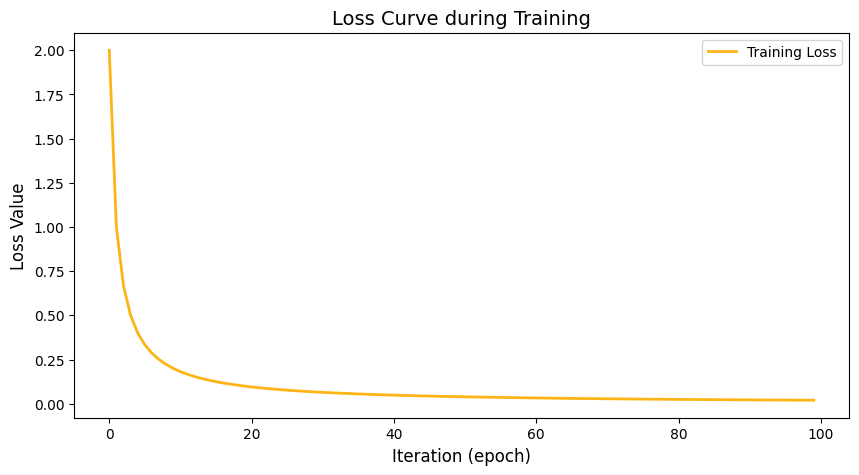

In [2]:
## Example
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import sleep

loss_history = []
iterations = []

pbar = tqdm(range(100), colour='blue',desc='Training') # desc :进度条名称
for epoch in pbar:
    sleep(0.05)
    current_loss = 2 / (epoch + 1)
    loss_history.append(current_loss)
    iterations.append(epoch)
    pbar.set_postfix(Loss=f"{current_loss:.4f}",status="Progression")
    if epoch >= 50:
        pbar.colour = 'cyan'  # 运行中动态改变颜色
        pbar.set_postfix(Loss=f"{current_loss:.4f}", status="Optimization")
pbar.close()
plt.figure(figsize=(10, 5))
plt.plot(iterations, loss_history, label='Training Loss', color='#FDB515', linewidth=2)
plt.title('Loss Curve during Training', fontsize=14)
plt.xlabel('Iteration (epoch)', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(False)
plt.legend()
# 标注颜色切换的点

plt.show()

In [11]:
pbar = tqdm(total=100, colour='cyan',desc='Training')
for epoch in range(100):
    sleep(0.01)
    pbar.update(1)
pbar.close()

Training: 100%|██████████| 100/100 [00:01<00:00, 81.68it/s]


可以使用tqdm包装所有可迭代的对象，包括惰性取值的迭代器和生成器

In [10]:
# 列表
age = ['11y','12y','13y','14y','15y']
Age = tqdm(age , desc= 'Growing', colour='cyan')
for i in Age:
    sleep(0.5)

Growing: 100%|██████████| 5/5 [00:02<00:00,  1.97it/s]


In [3]:
# 生成器
def generator():
    for i in range(50):
        yield i

for _ in tqdm(generator()):
    sleep(0.5)

14it [00:07,  1.95it/s]


KeyboardInterrupt: 

In [23]:
for _ in tqdm(generator(),total=50,colour='cyan'):
    sleep(0.05)

100%|██████████| 50/50 [00:02<00:00, 18.00it/s]


惰性取值tqdm无法获得实际的总的的数目，因此无法显示进度，人为规定一个total指标

## Manual Setting
可以手动设置进度条，在代码的各个位置都能显示代码运行的进度，不用拘泥于for循环

In [9]:
pbar = tqdm(total=100,desc='Manual',colour='red')
pbar.update(10)
sleep(2)
pbar.update(20)
sleep(2)
pbar.update(70)
pbar.close()

Manual: 100%|██████████| 100/100 [00:04<00:00, 24.93it/s]


In [2]:
with tqdm(total=100,desc='Manual',colour='red') as pbar:
    pbar.update(10)
    sleep(2)
    pbar.update(20)
    sleep(2)
    pbar.update(70)

Manual: 100%|██████████| 100/100 [00:04<00:00, 24.92it/s]
